# Fraud Detection - Model Training

- Load clean data
- Feature and target
- Imputing
- Train-test split
- Build and train multiple classifiers
- Model comparison (precision, recall, F1, ROC-AUC)
- ROC curve comparison
- Best model selection + confusion matrix + feature importance
- Financial impact analysis
- Save best model

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
import joblib
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")
print("import done")

import done


In [2]:
# Load clean data

data = pd.read_csv("cleaned_fraud_data.csv")
data.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,181.0,0.0,0.0,0.0,1
1,1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1
2,1,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1
3,1,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1
4,1,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1


In [4]:
# Back-up

df = data.copy()

In [5]:
# Feature and target

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

# Numeric and Categorical Features

num_features = X.select_dtypes(include="number").columns.to_list()
cat_features = X.select_dtypes(include="str").columns.to_list()

print("Numerical Features:\n", num_features)
print("\nCategorical Features:\n", cat_features)

Numerical Features:
 ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

Categorical Features:
 ['type']


# Data Pre-processing

In [6]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False, dtype=np.int64, drop="first"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num_transformer", num_pipeline, num_features),
    ("cat_transformer", cat_pipeline, cat_features)
])

In [7]:
# Train-test split (stratified because of the ~10% fraud imbalance)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [10]:
# Models + hyperparameter grids

models = {
    "LogisticRegression": (
        LogisticRegression(max_iter=1000, solver="liblinear", class_weight="balanced"),
        {"model__C": [0.01, 0.1, 1, 10]}
    ),
    "RandomForest": (
        RandomForestClassifier(random_state=42, class_weight="balanced"),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20]
        }
    ),
    "GradientBoosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3, 4]
        }
    ),
}
print("Models to train:", list(models.keys()))

Models to train: ['LogisticRegression', 'RandomForest', 'GradientBoosting']


In [11]:
# Model training + evaluation

results = []
fitted_models = {}
best_model = None
best_model_name = None
best_cv_score = 0

for name, (model, params) in models.items():
    print(f"{name} is running...")
    pipe = Pipeline(steps=[
        ("processor", preprocessor),
        ("model", model)
    ])
    grid = GridSearchCV(estimator=pipe, param_grid=params, cv=5,
                         scoring="roc_auc", n_jobs=-1)
    grid.fit(X_train, y_train)

    fitted_models[name] = grid.best_estimator_

    # Predictions
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]

    # Evaluation metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Best_Params": grid.best_params_,
        "CV_ROC_AUC": grid.best_score_,
        "Test_Precision": precision,
        "Test_Recall": recall,
        "Test_F1": f1,
        "Test_ROC_AUC": roc_auc
    })

    if grid.best_score_ > best_cv_score:
        best_cv_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name

    print(f"{name} done. CV ROC-AUC: {grid.best_score_:.4f} | Test ROC-AUC: {roc_auc:.4f}")

print(f"\nBest model based on CV ROC-AUC: {best_model_name}")

LogisticRegression is running...
LogisticRegression done. CV ROC-AUC: 0.9974 | Test ROC-AUC: 0.9933
RandomForest is running...
RandomForest done. CV ROC-AUC: 0.9999 | Test ROC-AUC: 0.9999
GradientBoosting is running...
GradientBoosting done. CV ROC-AUC: 0.9999 | Test ROC-AUC: 0.9996

Best model based on CV ROC-AUC: RandomForest


### Model Comparison

In [12]:
result_df = pd.DataFrame(results).sort_values(by="Test_ROC_AUC", ascending=False)
result_df.drop(columns="Best_Params")

,Model,CV_ROC_AUC,Test_Precision,Test_Recall,Test_F1,Test_ROC_AUC
1,RandomForest,0.999913,1.00000,0.986842,0.993377,0.999923
2,GradientBoosting,0.999904,1.00000,0.973684,0.986667,0.999614
0,LogisticRegression,0.997387,0.88664,0.960526,0.922105,0.993253


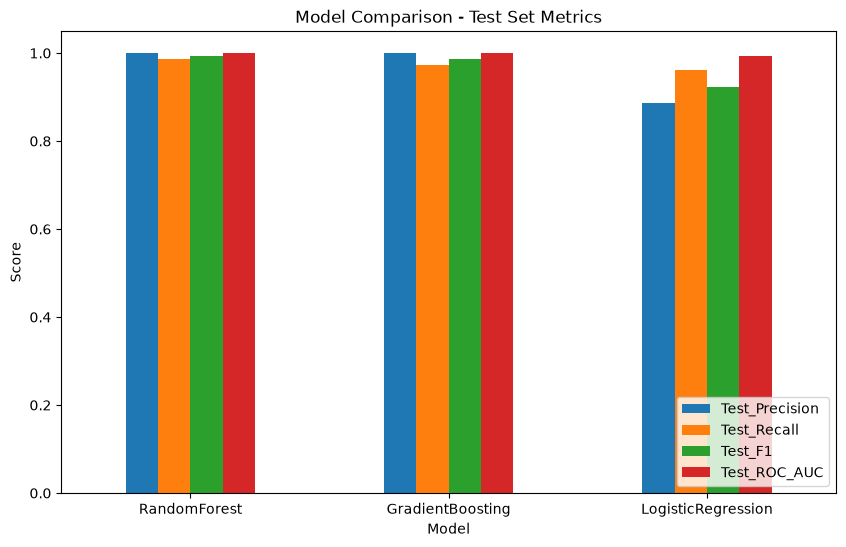

In [18]:
metrics_to_plot = result_df.set_index("Model")[["Test_Precision", "Test_Recall", "Test_F1", "Test_ROC_AUC"]]
metrics_to_plot.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison - Test Set Metrics")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

### ROC Curve Comparison

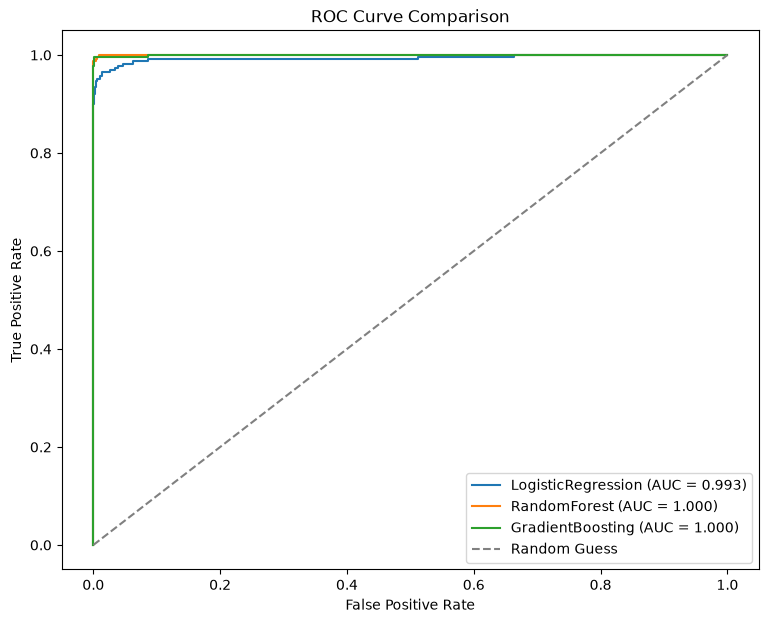

In [19]:
plt.figure(figsize=(9, 7))

for name, fitted in fitted_models.items():
    y_proba = fitted.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.show()

### Best Model - Confusion Matrix & Classification Report

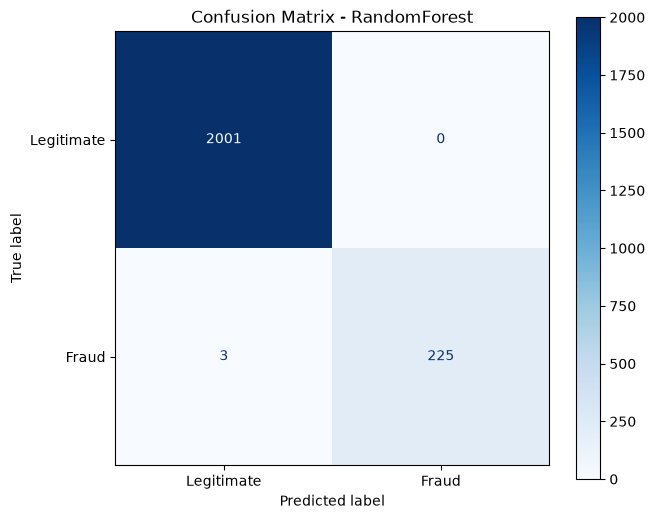

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      2001
       Fraud       1.00      0.99      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      1.00      2229
weighted avg       1.00      1.00      1.00      2229



In [15]:
y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Fraud"])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["Legitimate", "Fraud"]))

### Save Best Model

In [16]:
BEST_MODEL_PATH = "best_fraud_model.pkl"
joblib.dump(best_model, BEST_MODEL_PATH)

print(f"Best trained model: {best_model_name}")
print(f"Saved to: {BEST_MODEL_PATH}")

Best trained model: RandomForest
Saved to: best_fraud_model.pkl


In [20]:
print(f"Best-performing model: {best_model_name}")
print(f"Test ROC-AUC: {result_df.iloc[0]['Test_ROC_AUC']:.2f}")

Best-performing model: RandomForest
Test ROC-AUC: 1.00
